# Customer Churn Prediction and Customer Segmentation 

### Author
Rishabh Bhardwaj

## Project Overview

Customer churn is one of the biggest challenges faced by subscription-based businesses. This project predicts whether a customer is likely to leave the company using a Random Forest Classifier. Additionally, K-Means Clustering is applied to segment customers into meaningful business groups based on their tenure, spending behaviour, and churn probability.

The project demonstrates complete machine learning workflow including:

- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building
- Model Evaluation
- Hyperparameter Tuning
- Customer Segmentation
- Business Insights

In [ ]:

# Customer Churn Prediction
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.cluster import KMeans

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


# Dataset

The dataset used in this project is the Telco Customer Churn Dataset.

It contains customer demographic information, service details, contract information, billing information, and churn status.

Target Variable:

- Churn Value
    - 1 → Customer Left
    - 0 → Customer Stayed

In [ ]:
df = pd.read_csv("../data/Telco_customer_churn.csv")

print("Dataset Loaded Successfully!\n")

print("Shape of Dataset:", df.shape)

df.head()

Dataset Loaded Successfully!

Shape of Dataset: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
# Basic Dataset Information

print("Dataset Information\n")
df.info()

print("\n\nMissing Values\n")
print(df.isnull().sum())

print("\n\nStatistical Summary\n")
display(df.describe())

print("\nCategorical Columns Summary\n")
display(df.describe(include='object'))

Dataset Information

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Servi

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000



Categorical Columns Summary



,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531,2,20
top,3668-QPYBK,United States,California,Los Angeles,"33.964131, -118.272783",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11,5174,192


# Data Cleaning and Feature Selection

Remove unnecessary columns and prepare the dataset for machine learning.

In [ ]:
data = df.copy()

drop_columns = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

data.drop(columns=drop_columns, inplace=True)

data['Total Charges'] = pd.to_numeric(data['Total Charges'], errors='coerce')

# Fill missing values
data['Total Charges'].fillna(data['Total Charges'].median(), inplace=True)

print("Dataset Shape after Cleaning:", data.shape)

data.head()

Dataset Shape after Cleaning: (7043, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


# Categorical Feature Encoding

Convert categorical variables into numerical values using One-Hot Encoding.

In [ ]:
data = pd.get_dummies(data, drop_first=True)

print("Encoding completed successfully!")
print("New Shape:", data.shape)

data.head()

Encoding completed successfully!
New Shape: (7043, 31)


,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


# Correlation Analysis

Visualize relationships between features using a correlation heatmap.

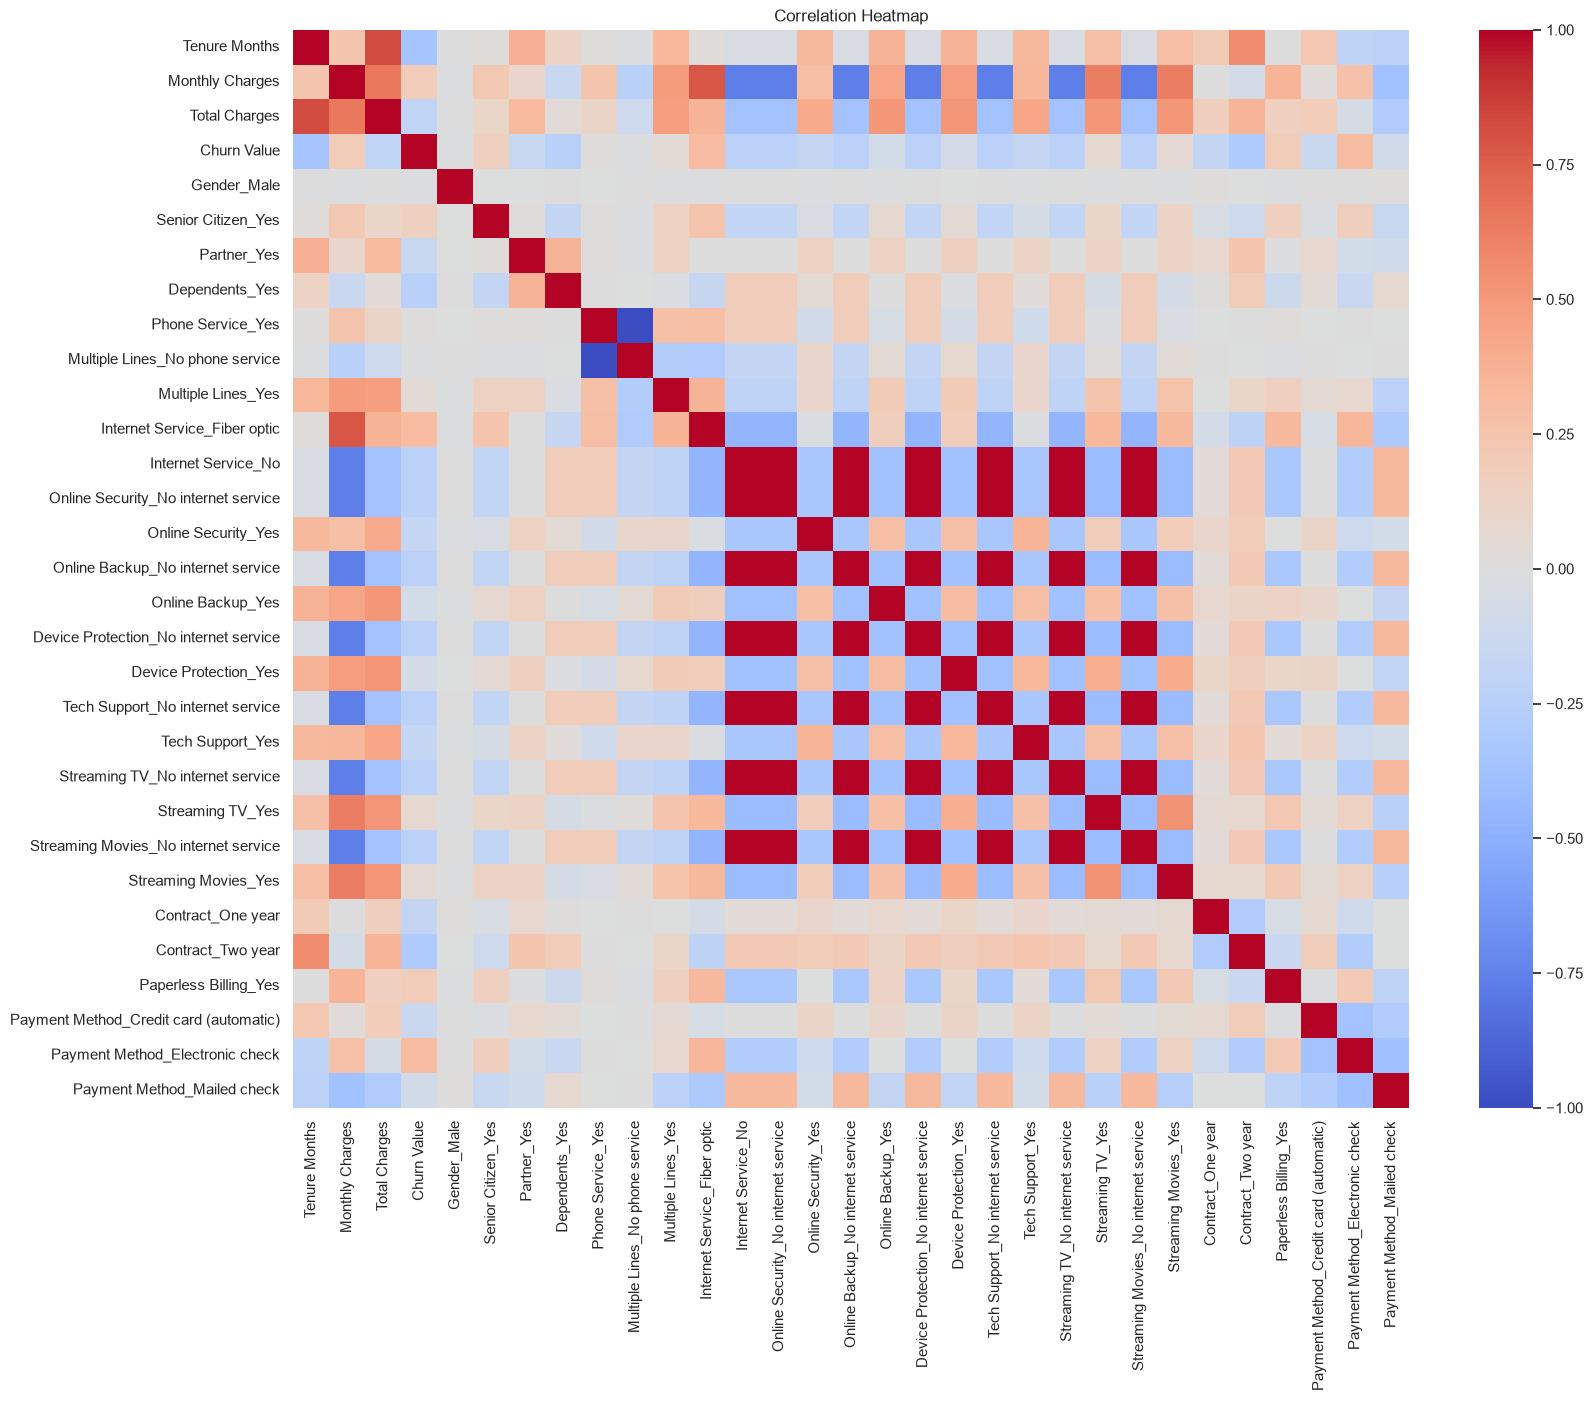

In [ ]:
plt.figure(figsize=(18, 14))

corr = data.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

# Random Forest Classification

# Feature and Target Selection

Separate independent features (X) and target variable (y).

In [ ]:
X = data.drop("Churn Value", axis=1)
Y = data["Churn Value"]

print("Features Shape :", X.shape)
print("Target Shape :", Y.shape)

Features Shape : (7043, 30)
Target Shape : (7043,)


# Train-Test Split

Split the dataset into training and testing sets.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


# Model Training

Train a Random Forest Classifier to predict customer churn.

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [12]:
Y_pred = rf.predict(X_test)

Y_pred[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1])

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, Y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7778566359119943


In [14]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



# Confusion Matrix

Visualize correct and incorrect predictions.

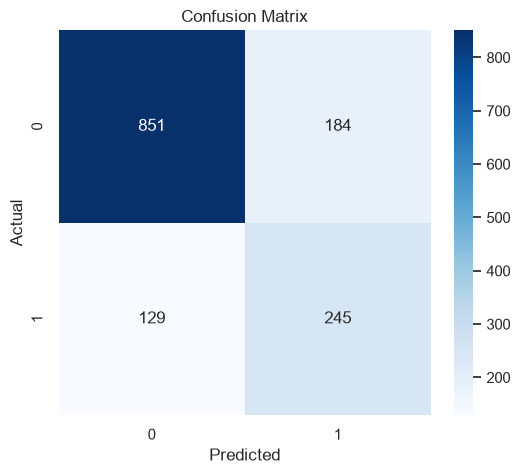

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ROC Curve and AUC Score

Measure the classifier's discrimination capability.

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf.predict_proba(X_test)

churn_prob = y_prob[:,1]

fpr, tpr, threshold = roc_curve(Y_test, churn_prob)

auc_score = roc_auc_score(Y_test, churn_prob)

print("ROC AUC Score:", auc_score)

ROC AUC Score: 0.8356377069932057


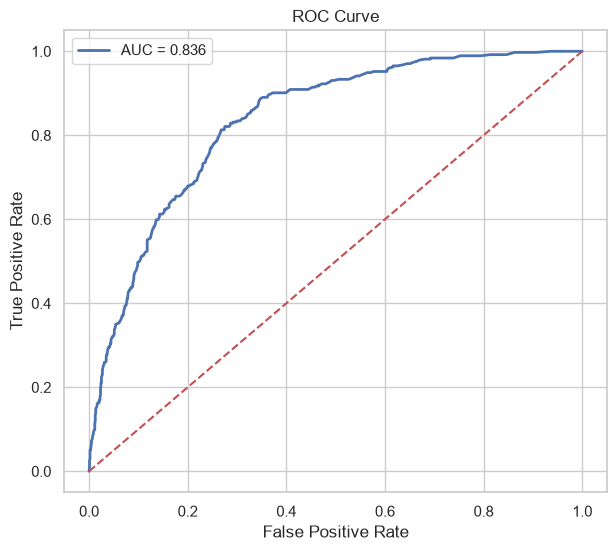

In [17]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
# Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    Y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.77927608 0.79276082 0.76437189 0.77982955 0.77982955]

Average Accuracy:
0.779213578295374


# Hyperparameter Tuning

Optimize the Random Forest model using GridSearchCV.

In [20]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    parameters,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, Y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Accuracy:
0.7845185429179781


In [ ]:
# Feature Importance
# Identify the most influential features affecting customer churn.
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
2,Total Charges,0.169878
0,Tenure Months,0.161980
1,Monthly Charges,0.143466
25,Contract_Two year,0.060772
6,Dependents_Yes,0.050603
10,Internet Service_Fiber optic,0.042388
28,Payment Method_Electronic check,0.037054
24,Contract_One year,0.028158
13,Online Security_Yes,0.026233
3,Gender_Male,0.024550


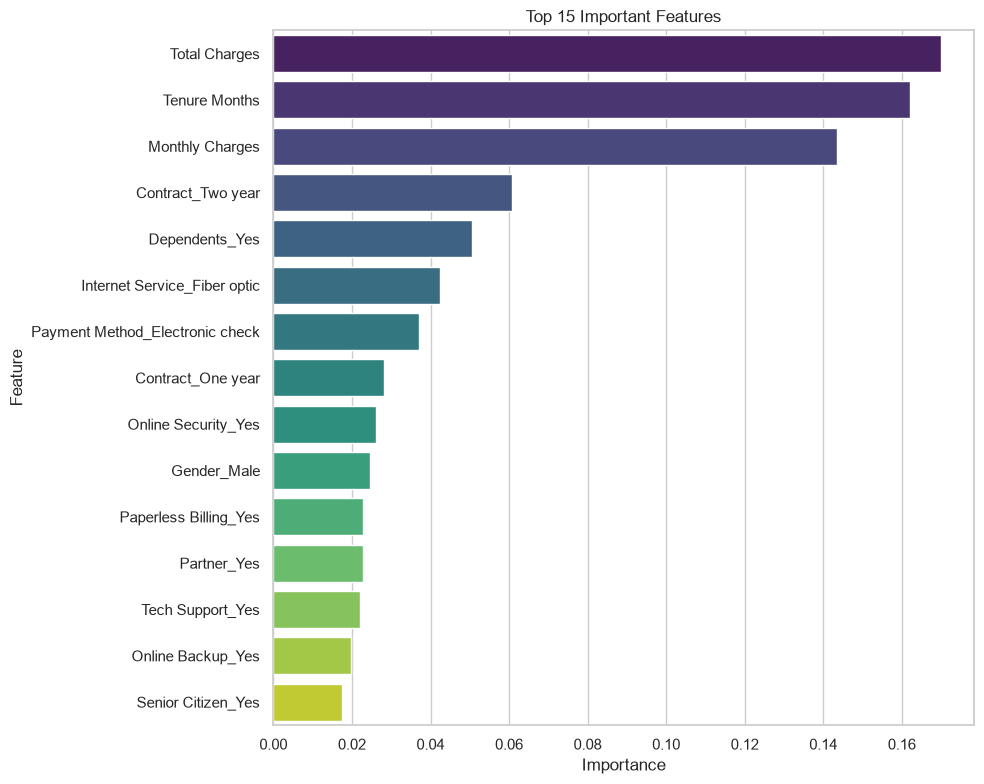

In [22]:
plt.figure(figsize=(10,8))

sns.barplot(

    x="Importance",

    y="Feature",

    data=importance.head(15),

    palette="viridis"

)

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.savefig("../images/feature_importance.png")

plt.show()

# Customer Segmentation

Create a dataset for customer segmentation using churn probability and customer attributes.

In [25]:
segmentation=pd.DataFrame({

"Tenure Months":df["Tenure Months"],

"Monthly Charges":df["Monthly Charges"],

"Total Charges":pd.to_numeric(df["Total Charges"],errors='coerce'),

"Churn Probability":rf.predict_proba(X)[:,1]

})

In [26]:
segmentation=segmentation.dropna()

In [27]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

scaled=scaler.fit_transform(segmentation)

# Elbow Method

Determine the optimal number of customer clusters.

In [28]:
from sklearn.cluster import KMeans

wcss=[]

for i in range(1,11):

    kmeans=KMeans(

        n_clusters=i,

        random_state=42,

        n_init=10

    )

    kmeans.fit(scaled)

    wcss.append(kmeans.inertia_)

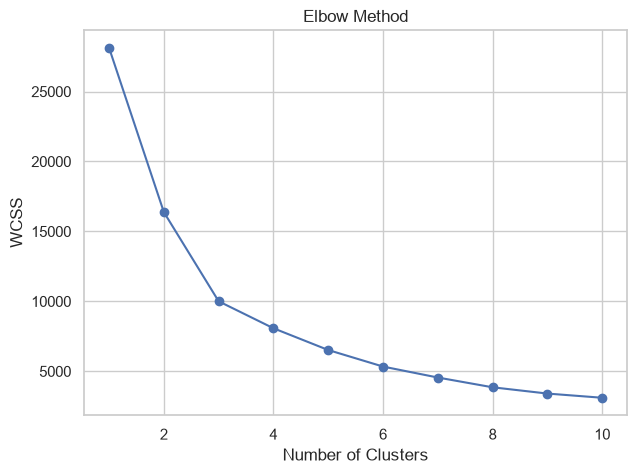

In [29]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.savefig("../images/elbow_method.png")

plt.show()

## Elbow Method Interpretation

The Elbow Method was used to determine the optimal number of clusters for customer segmentation. The Within-Cluster Sum of Squares (WCSS) decreases significantly until **k = 3**, after which the reduction becomes more gradual.

Therefore, **3 clusters** were selected as the optimal number for K-Means clustering, balancing model simplicity and cluster quality.

# Final K-Means Clustering

Train the K-Means model using the selected number of clusters.

In [31]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled)

segmentation["Cluster"] = clusters

segmentation.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.950000,0
1,2,70.70,151.65,0.953333,0
2,8,99.65,820.50,0.970000,0
3,28,104.80,3046.05,0.886667,0
4,49,103.70,5036.30,0.900000,2


# Cluster Summary

Analyze the average characteristics of each customer segment.

In [32]:
cluster_summary = segmentation.groupby("Cluster").mean()

cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,11.884104,74.003665,951.847183,0.781347
1,28.334828,36.625934,972.958614,0.105623
2,58.086977,90.243902,5234.537069,0.189327


# Cluster Labeling

Assign meaningful business names to each customer segment.

In [33]:
cluster_names = {
    0: "Budget Loyal Customers",
    1: "High Risk New Customers",
    2: "Loyal Premium Customers"
}

segmentation["Cluster Segment"] = segmentation["Cluster"].map(cluster_names)

segmentation.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.950000,0,Budget Loyal Customers
1,2,70.70,151.65,0.953333,0,Budget Loyal Customers
2,8,99.65,820.50,0.970000,0,Budget Loyal Customers
3,28,104.80,3046.05,0.886667,0,Budget Loyal Customers
4,49,103.70,5036.30,0.900000,2,Loyal Premium Customers


In [36]:
cluster_summary = segmentation.groupby("Cluster")[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Probability"
]].mean()

cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,11.884104,74.003665,951.847183,0.781347
1,28.334828,36.625934,972.958614,0.105623
2,58.086977,90.243902,5234.537069,0.189327


In [37]:
cluster_names = {
    0: "High Risk New Customers",
    1: "Budget Loyal Customers",
    2: "Premium Loyal Customers"
}

segmentation["Cluster Segment"] = segmentation["Cluster"].map(cluster_names)

# Customer Segmentation by Monthly Charges

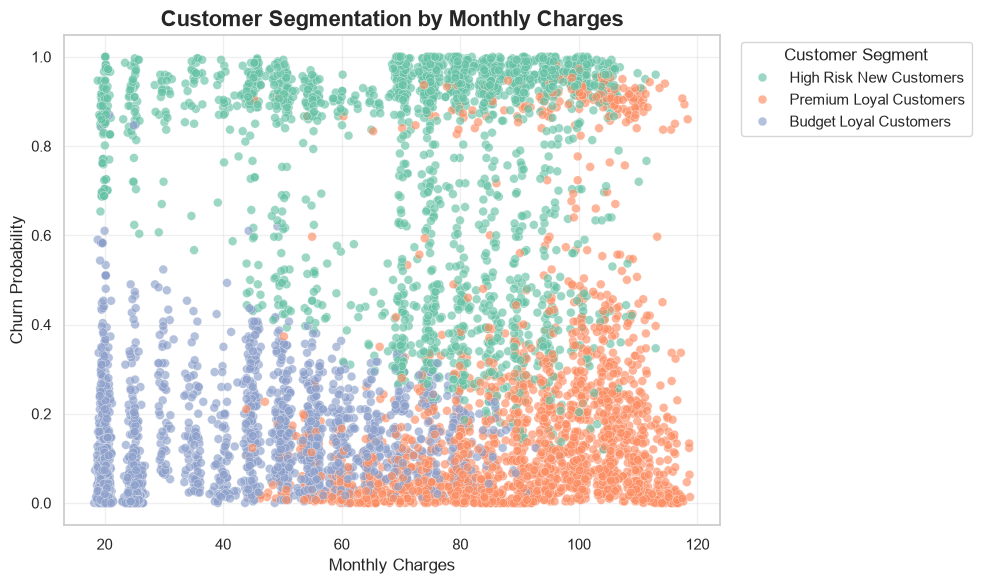

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=segmentation,
    x="Monthly Charges",
    y="Churn Probability",
    hue="Cluster Segment",
    palette="Set2",
    s=40,
    alpha=0.65,
    edgecolor="white",
    linewidth=0.3
)

plt.title("Customer Segmentation by Monthly Charges", fontsize=16, fontweight="bold")
plt.xlabel("Monthly Charges", fontsize=12)
plt.ylabel("Churn Probability", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(title="Customer Segment",
           bbox_to_anchor=(1.02,1),
           loc="upper left")

plt.tight_layout()

plt.savefig("../images/customer_segments_monthly.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Customer Segmentation by Tenure

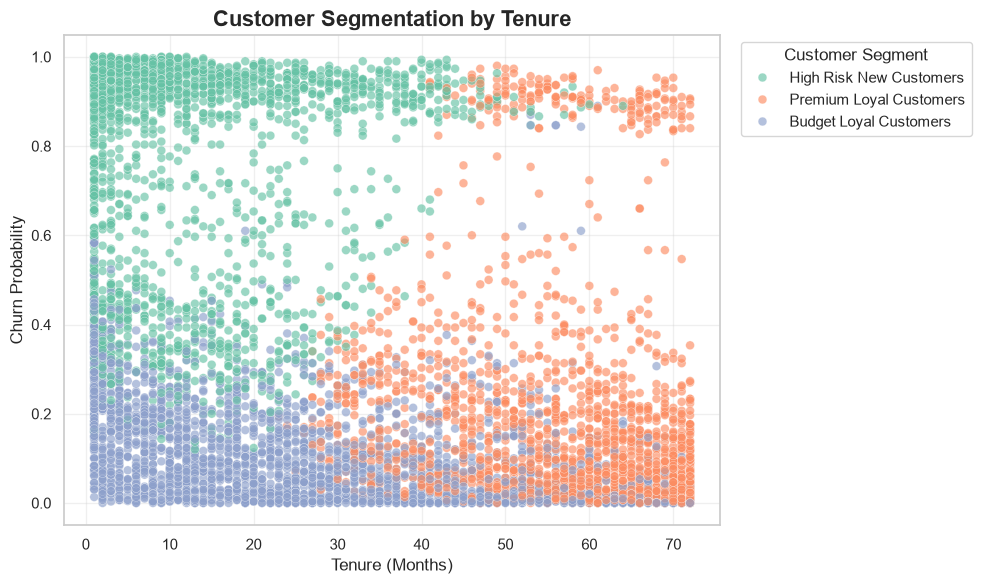

In [41]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=segmentation,
    x="Tenure Months",
    y="Churn Probability",
    hue="Cluster Segment",
    palette="Set2",
    s=40,
    alpha=0.65,
    edgecolor="white",
    linewidth=0.3
)

plt.title("Customer Segmentation by Tenure", fontsize=16, fontweight="bold")
plt.xlabel("Tenure (Months)", fontsize=12)
plt.ylabel("Churn Probability", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../images/customer_segments_tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Customer Segmentation by Total Charges

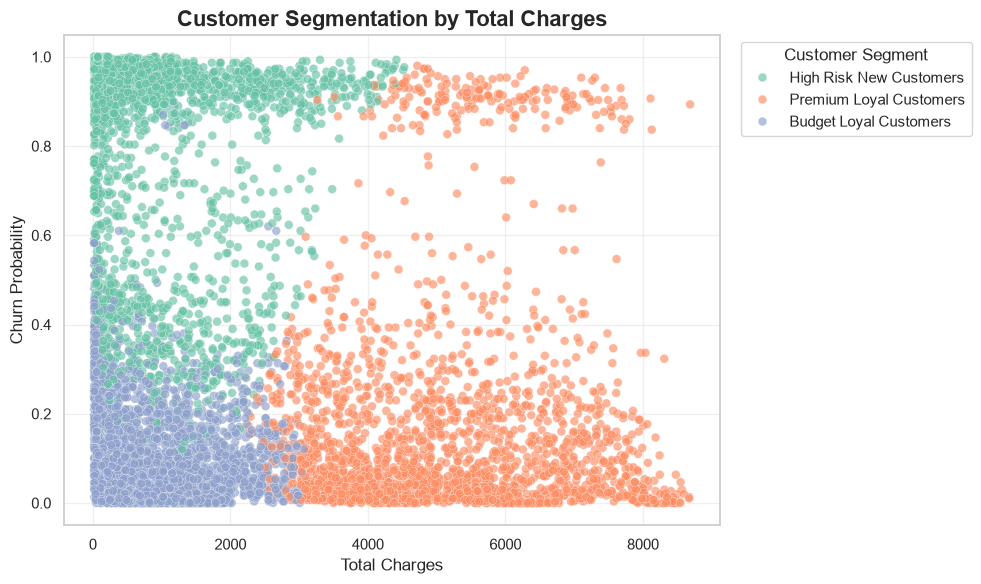

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=segmentation,
    x="Total Charges",
    y="Churn Probability",
    hue="Cluster Segment",
    palette="Set2",
    s=40,
    alpha=0.65,
    edgecolor="white",
    linewidth=0.3
)

plt.title("Customer Segmentation by Total Charges", fontsize=16, fontweight="bold")
plt.xlabel("Total Charges", fontsize=12)
plt.ylabel("Churn Probability", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../images/customer_segments_total.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Conclusion

This project successfully predicts customer churn using a Random Forest Classifier and segments customers using K-Means Clustering.

## Results

- Accuracy: **77.79%**
- ROC-AUC Score: **0.8356**
- Cross Validation Accuracy: **77.92%**
- Best GridSearchCV Accuracy: **78.45%**

## Key Findings

- Total Charges is the most important feature influencing churn.
- Customers with longer tenure are less likely to churn.
- Monthly Charges significantly impact customer retention.
- Three distinct customer segments were identified:
  - Budget Loyal Customers
  - High Risk New Customers
  - Premium Loyal Customers

This project demonstrates an end-to-end machine learning workflow, including data preprocessing, visualization, model training, evaluation, hyperparameter tuning, and customer segmentation.